# Get the Bids to be used for SNP filtering

In [44]:
library(data.table)
library(UpSetR)
library(stringr)
library(ggplot2)

## 1. TREs

### 1A. Read in DE results

Warning message in fread("../results/DESeq2/res_NonTSS_ADP_vs_Veh_par_rat_Wd_GeneHK.txt"):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr8:81587535-81588539,1412.9620,-5.377938,0.5399221,-9.960580,2.267356e-23,6.093066e-19
chr3:152621003-152621763,163.5758,-4.625536,0.6121937,-7.555674,4.166963e-14,5.598940e-10


`stat_bin()` using `bins = 30`. Pick better value with
`binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with
`binwidth`.
Warning message:
“Removed 12085 rows containing non-finite outside the scale
range (`stat_bin()`).”


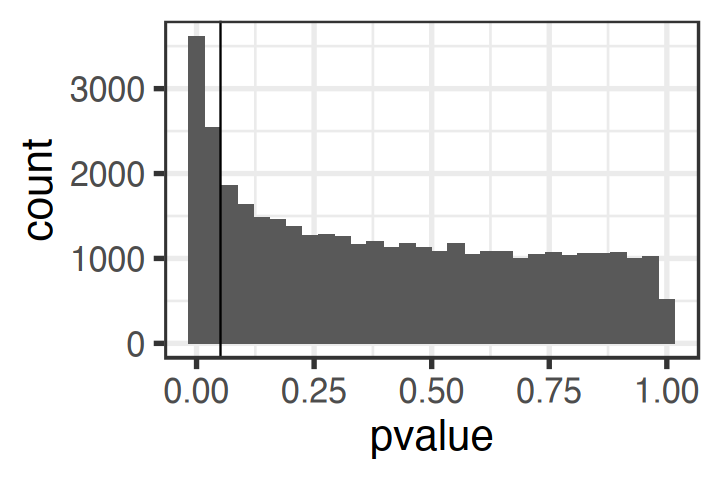

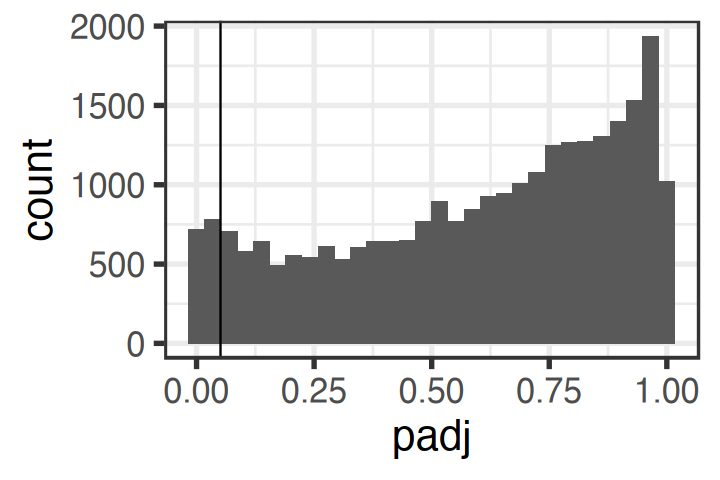

In [45]:
adp <- fread("../results/DESeq2/res_NonTSS_ADP_vs_Veh_par_rat_Wd_GeneHK.txt")
adp[1:2,]
options(repr.plot.height=4, repr.plot.width=6)
ggplot(adp, aes(x=pvalue)) + geom_histogram() + theme_bw(base_size=25) + geom_vline(xintercept=0.05)
ggplot(adp, aes(x=padj)) + geom_histogram() + theme_bw(base_size=25) + geom_vline(xintercept=0.05)

# regions changing according to 0.05
up_adp = adp[adp$log2FoldChange > 0 & adp$padj < 0.01,]$V1
down_adp = adp[adp$log2FoldChange < 0 & adp$padj < 0.01,]$V1

In [46]:
# UPM
upm30 <- fread("../results/DESeq2/res_NonTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.txt")
upm120 <- fread("../results/DESeq2/res_NonTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.txt")

# regions changing according to 0.05
up_upm30 = upm30[upm30$log2FoldChange > 0 & upm30$padj < 0.001,]$V1
down_upm30 = upm30[upm30$log2FoldChange < 0 & upm30$padj < 0.001,]$V1

# regions changing according to 0.05
up_upm120 = upm120[upm120$log2FoldChange > 0 & upm120$padj < 0.001,]$V1
down_upm120 = upm120[upm120$log2FoldChange < 0 & upm120$padj < 0.001,]$V1

Warning message in fread("../results/DESeq2/res_NonTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.txt"):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in fread("../results/DESeq2/res_NonTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.txt"):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


In [47]:
# WSP
wsp30 <- fread("../results/DESeq2/res_NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt")
wsp120 <- fread("../results/DESeq2/res_NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt")

# regions changing according to 0.05
up_wsp30 = wsp30[wsp30$log2FoldChange > 0 & wsp30$padj < 0.001,]$V1
down_wsp30 = wsp30[wsp30$log2FoldChange < 0 & wsp30$padj < 0.001,]$V1

# regions changing according to 0.05
up_wsp120 = wsp120[wsp120$log2FoldChange > 0 & wsp120$padj < 0.001,]$V1
down_wsp120 = wsp120[wsp120$log2FoldChange < 0 & wsp120$padj < 0.001,]$V1

Warning message in fread("../results/DESeq2/res_NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt"):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in fread("../results/DESeq2/res_NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt"):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


### 1B. Get the Union of all Sig Calls and Intersect between UPM and WSP (and ADP)

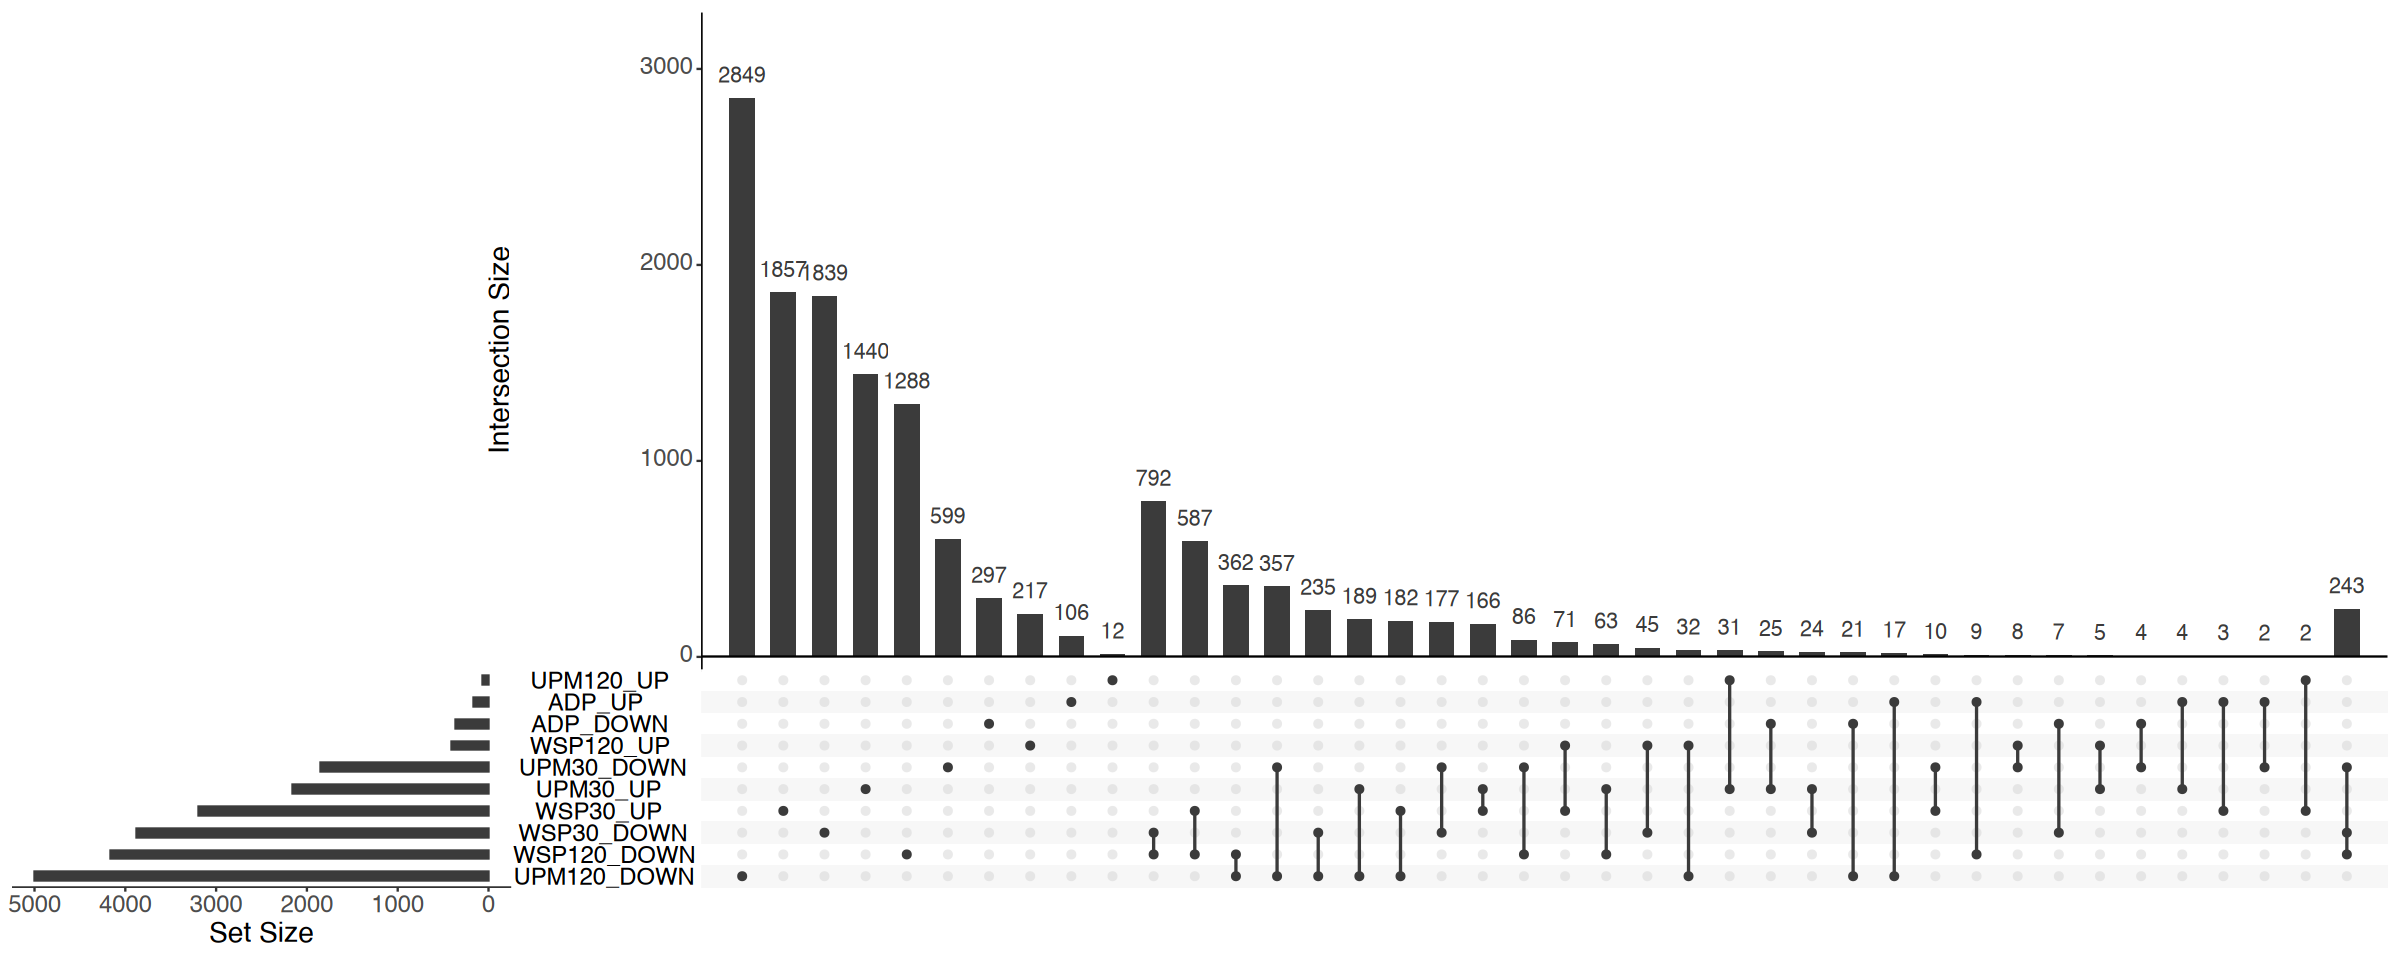

In [48]:
sig_calls = list("ADP_UP"=up_adp, "ADP_DOWN"=down_adp, 
                 "UPM30_UP"=up_upm30, "UPM30_DOWN"=down_upm30, 
                  "UPM120_UP"=up_upm120, "UPM120_DOWN"=down_upm120, 
                 "WSP30_UP"=up_wsp30, "WSP30_DOWN"=down_wsp30, 
                  "WSP120_UP"=up_wsp120, "WSP120_DOWN"=down_wsp120)
options(repr.plot.width=20, repr.plot.height=8)
upset(fromList(sig_calls), nsets=10, text.scale=2)

In [49]:
# how many would it be if I considered all sig calls?
all_sig = union(up_adp, 
                union(down_adp, 
                      union(up_upm30, 
                            union(down_upm30, 
                                  union(up_upm120, 
                                        union(down_upm120, 
                                              union(up_wsp30, 
                                                    union(down_wsp30, 
                                                          union(up_wsp120, down_wsp120)))))))))
length(all_sig)

[1] 15196

[1] 9237

[1] 8073

[1] 526

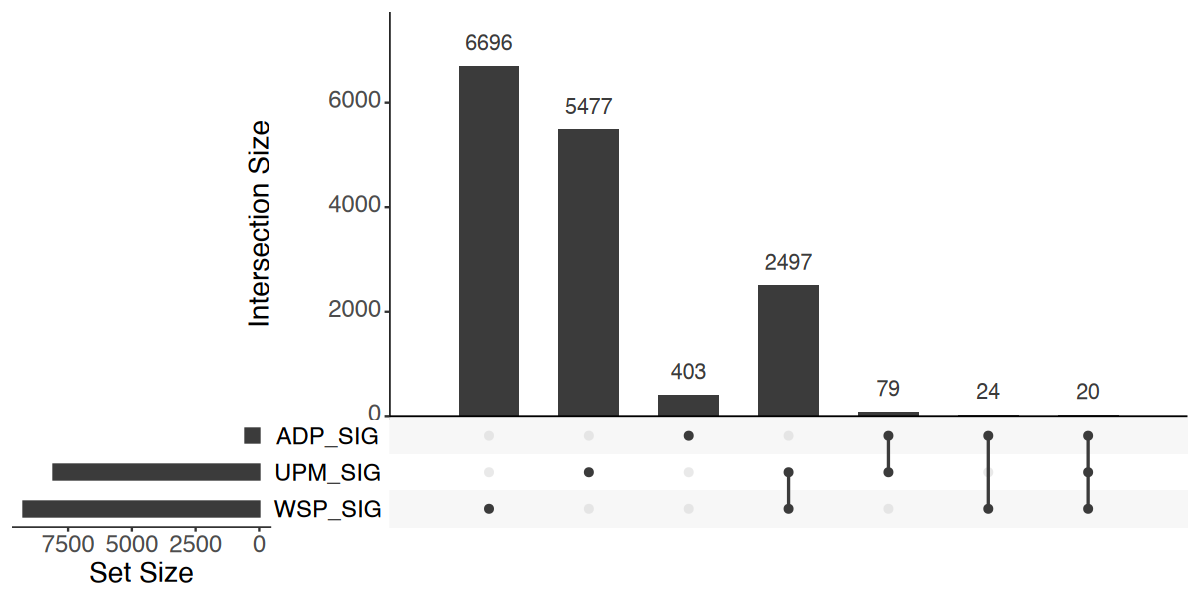

In [50]:
upm_sig = union(union(up_upm120, down_upm120), union(up_upm30, down_upm30))
wsp_sig = union(union(up_wsp120, down_wsp120), union(up_wsp30, down_wsp30))
adp_sig = union(up_adp, down_adp)

sig_calls = list("ADP_SIG"=adp_sig, "UPM_SIG"=upm_sig, 
                 "WSP_SIG"=wsp_sig)
options(repr.plot.width=10, repr.plot.height=5)
upset(fromList(sig_calls), nsets=3, text.scale=2)

length(wsp_sig)
length(upm_sig)
length(adp_sig)

In [51]:
both_sig = intersect(upm_sig, wsp_sig)
shared_sig = intersect(both_sig, adp_sig)
length(shared_sig)
length(both_sig)

[1] 20

[1] 2517

### 1C. Save the set while acknowledging where they came from

In [52]:
# Create a named list of your vectors
all_lists <- list(
  up_adp = up_adp,
  down_adp = down_adp,
  up_upm30 = up_upm30,
  down_upm30 = down_upm30,
  up_upm120 = up_upm120,
  down_upm120 = down_upm120,
  up_wsp30 = up_wsp30,
  down_wsp30 = down_wsp30,
  up_wsp120 = up_wsp120,
  down_wsp120 = down_wsp120
)

# Get all unique names
all_sig <- unique(unlist(all_lists))

# Create a data.frame indicating membership in each list
membership_df <- data.frame(name = all_sig)

# Add a column that lists which input lists each name appears in
membership_df$source_lists <- sapply(membership_df$name, function(gene) {
  paste(names(all_lists)[sapply(all_lists, function(lst) gene %in% lst)], collapse = ", ")
})

# View the result
head(membership_df)


,name,source_lists
,<chr>,<chr>
1,chr5:53288231-53288949,up_adp
2,chr22:37545127-37545883,up_adp
3,chr12:13179624-13180120,"up_adp, down_upm120, up_wsp30"
4,chr6:47726684-47727160,up_adp
5,chr12:13194425-13195275,up_adp
6,chr3:185335757-185336311,"up_adp, up_upm30, down_upm120"


In [16]:
# get the bed files
## ALL
split1 <- str_split_fixed(membership_df$name, ":", 2)
split2 <- str_split_fixed(split1[,2], "-", 2)
mu <- as.integer((as.integer(split2[,1]) + as.integer(split2[,2]))/2)
membership_df$start100 <- mu - 50
membership_df$stop100 <- mu + 50
membership_df$chrom <- split1[,1]
membership_df[1:3,]

,name,source_lists,start100,stop100,chrom
,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,chr5:53288231-53288949,up_adp,53288540,53288640,chr5
2,chr22:37545127-37545883,up_adp,37545455,37545555,chr22
3,chr12:13179624-13180120,"up_adp, down_upm120, up_wsp30",13179822,13179922,chr12


In [53]:
## UPM
split1 <- str_split_fixed(upm_sig, ":", 2)
split2 <- str_split_fixed(split1[,2], "-", 2)
mu <- as.integer((as.integer(split2[,1]) + as.integer(split2[,2]))/2)
upm_df = data.table("chrom"=split1[,1], "start"= mu - 50, "stop" = mu + 50, "name" = both_sig)
upm_df[1:2,]

Warning message in as.data.table.list(x, keep.rownames = keep.rownames, check.names = check.names, :
“Item 4 has 2517 rows but longest item has 8073; recycled with remainder.”


chrom,start,stop,name
<chr>,<dbl>,<dbl>,<chr>
chr5,399860,399960,chr5:399569-400251
chr15,74642462,74642562,chr5:372805-373803


In [18]:
## SHARED
split1 <- str_split_fixed(both_sig, ":", 2)
split2 <- str_split_fixed(split1[,2], "-", 2)
mu <- as.integer((as.integer(split2[,1]) + as.integer(split2[,2]))/2)
both_df = data.table("chrom"=split1[,1], "start"= mu - 50, "stop" = mu + 50, "name" = both_sig)
both_df[1:2,]

chrom,start,stop,name
<chr>,<dbl>,<dbl>,<chr>
chr5,399860,399960,chr5:399569-400251
chr5,373254,373354,chr5:372805-373803


In [20]:
dim(membership_df)
dim(both_df)

[1] 15196     5

[1] 2517    4

In [54]:
# write.table(membership_df[,c("chrom", "start100", "stop100", "name", "source_lists")], 
#                              "../results/SNP_analysis/TRE_SIGADPWSPUPM_100bp.bed", 
#             quote=FALSE, sep="\t", col.names=FALSE, row.names=FALSE)

write.table(upm_df, "../results/SNP_analysis/TRE_SIGUPM_100bp.bed", 
            quote=FALSE, sep="\t", col.names=FALSE, row.names=FALSE)

# write.table(both_df, "../results/SNP_analysis/TRE_SIGWSPandUPM_100bp.bed", 
#             quote=FALSE, sep="\t", col.names=FALSE, row.names=FALSE)

## 2. Gene TSSs

Warning message in fread("../results/DESeq2/res_Gene_ADP_vs_Veh_par_rat_Wd_GeneHK.txt"):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SERPINB3,1235.661,-4.927882,0.3124786,-15.77031,4.980821e-56,8.377243e-52
TIMP2,1959.986,4.292117,0.3218790,13.33457,1.456995e-40,1.225260e-36


`stat_bin()` using `bins = 30`. Pick better value with
`binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with
`binwidth`.
Warning message:
“Removed 333 rows containing non-finite outside the scale
range (`stat_bin()`).”


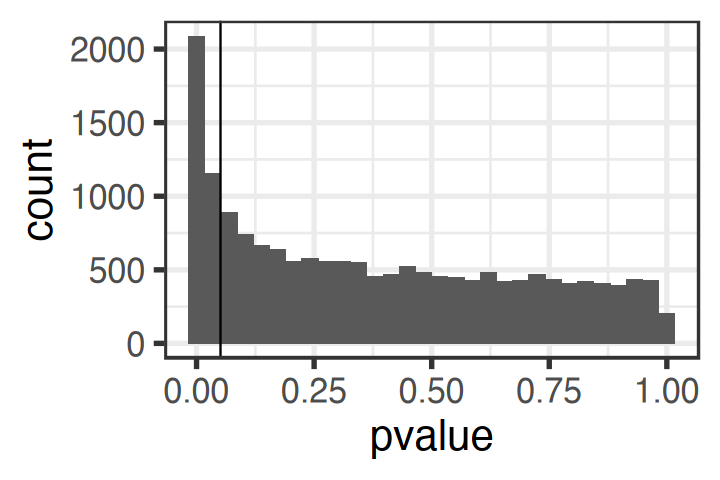

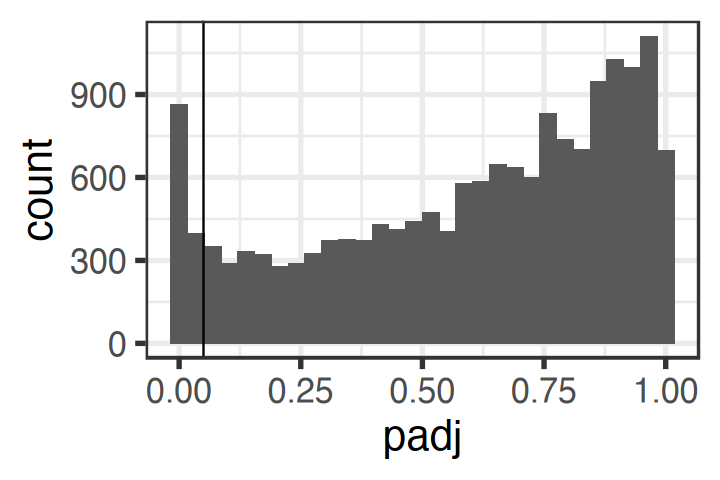

In [21]:
adp <- fread("../results/DESeq2/res_Gene_ADP_vs_Veh_par_rat_Wd_GeneHK.txt")
adp[1:2,]
options(repr.plot.height=4, repr.plot.width=6)
ggplot(adp, aes(x=pvalue)) + geom_histogram() + theme_bw(base_size=25) + geom_vline(xintercept=0.05)
ggplot(adp, aes(x=padj)) + geom_histogram() + theme_bw(base_size=25) + geom_vline(xintercept=0.05)

# regions changing according to 0.05
up_adp = adp[adp$log2FoldChange > 0 & adp$padj < 0.01,]$V1
down_adp = adp[adp$log2FoldChange < 0 & adp$padj < 0.01,]$V1

In [22]:
# UPM
upm30 <- fread("../results/DESeq2/res_Gene_UPM30_vs_Veh_par_rat_Wd_GeneHK.txt")
upm120 <- fread("../results/DESeq2/res_Gene_UPM120_vs_Veh_par_rat_Wd_GeneHK.txt")

# regions changing according to 0.05
up_upm30 = upm30[upm30$log2FoldChange > 0 & upm30$padj < 1e-10,]$V1
down_upm30 = upm30[upm30$log2FoldChange < 0 & upm30$padj < 1e-10,]$V1

# regions changing according to 0.05
up_upm120 = upm120[upm120$log2FoldChange > 0 & upm120$padj < 1e-10,]$V1
down_upm120 = upm120[upm120$log2FoldChange < 0 & upm120$padj < 1e-10,]$V1

Warning message in fread("../results/DESeq2/res_Gene_UPM30_vs_Veh_par_rat_Wd_GeneHK.txt"):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in fread("../results/DESeq2/res_Gene_UPM120_vs_Veh_par_rat_Wd_GeneHK.txt"):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


In [25]:
# WSP
wsp30 <- fread("../results/DESeq2/res_Gene_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt")
wsp120 <- fread("../results/DESeq2/res_Gene_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt")

# regions changing according to 0.05
up_wsp30 = wsp30[wsp30$log2FoldChange > 0 & wsp30$padj < 1e-10,]$V1
down_wsp30 = wsp30[wsp30$log2FoldChange < 0 & wsp30$padj < 1e-10,]$V1

# regions changing according to 0.05
up_wsp120 = wsp120[wsp120$log2FoldChange > 0 & wsp120$padj < 1e-10,]$V1
down_wsp120 = wsp120[wsp120$log2FoldChange < 0 & wsp120$padj < 1e-10,]$V1

Warning message in fread("../results/DESeq2/res_Gene_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt"):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in fread("../results/DESeq2/res_Gene_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt"):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


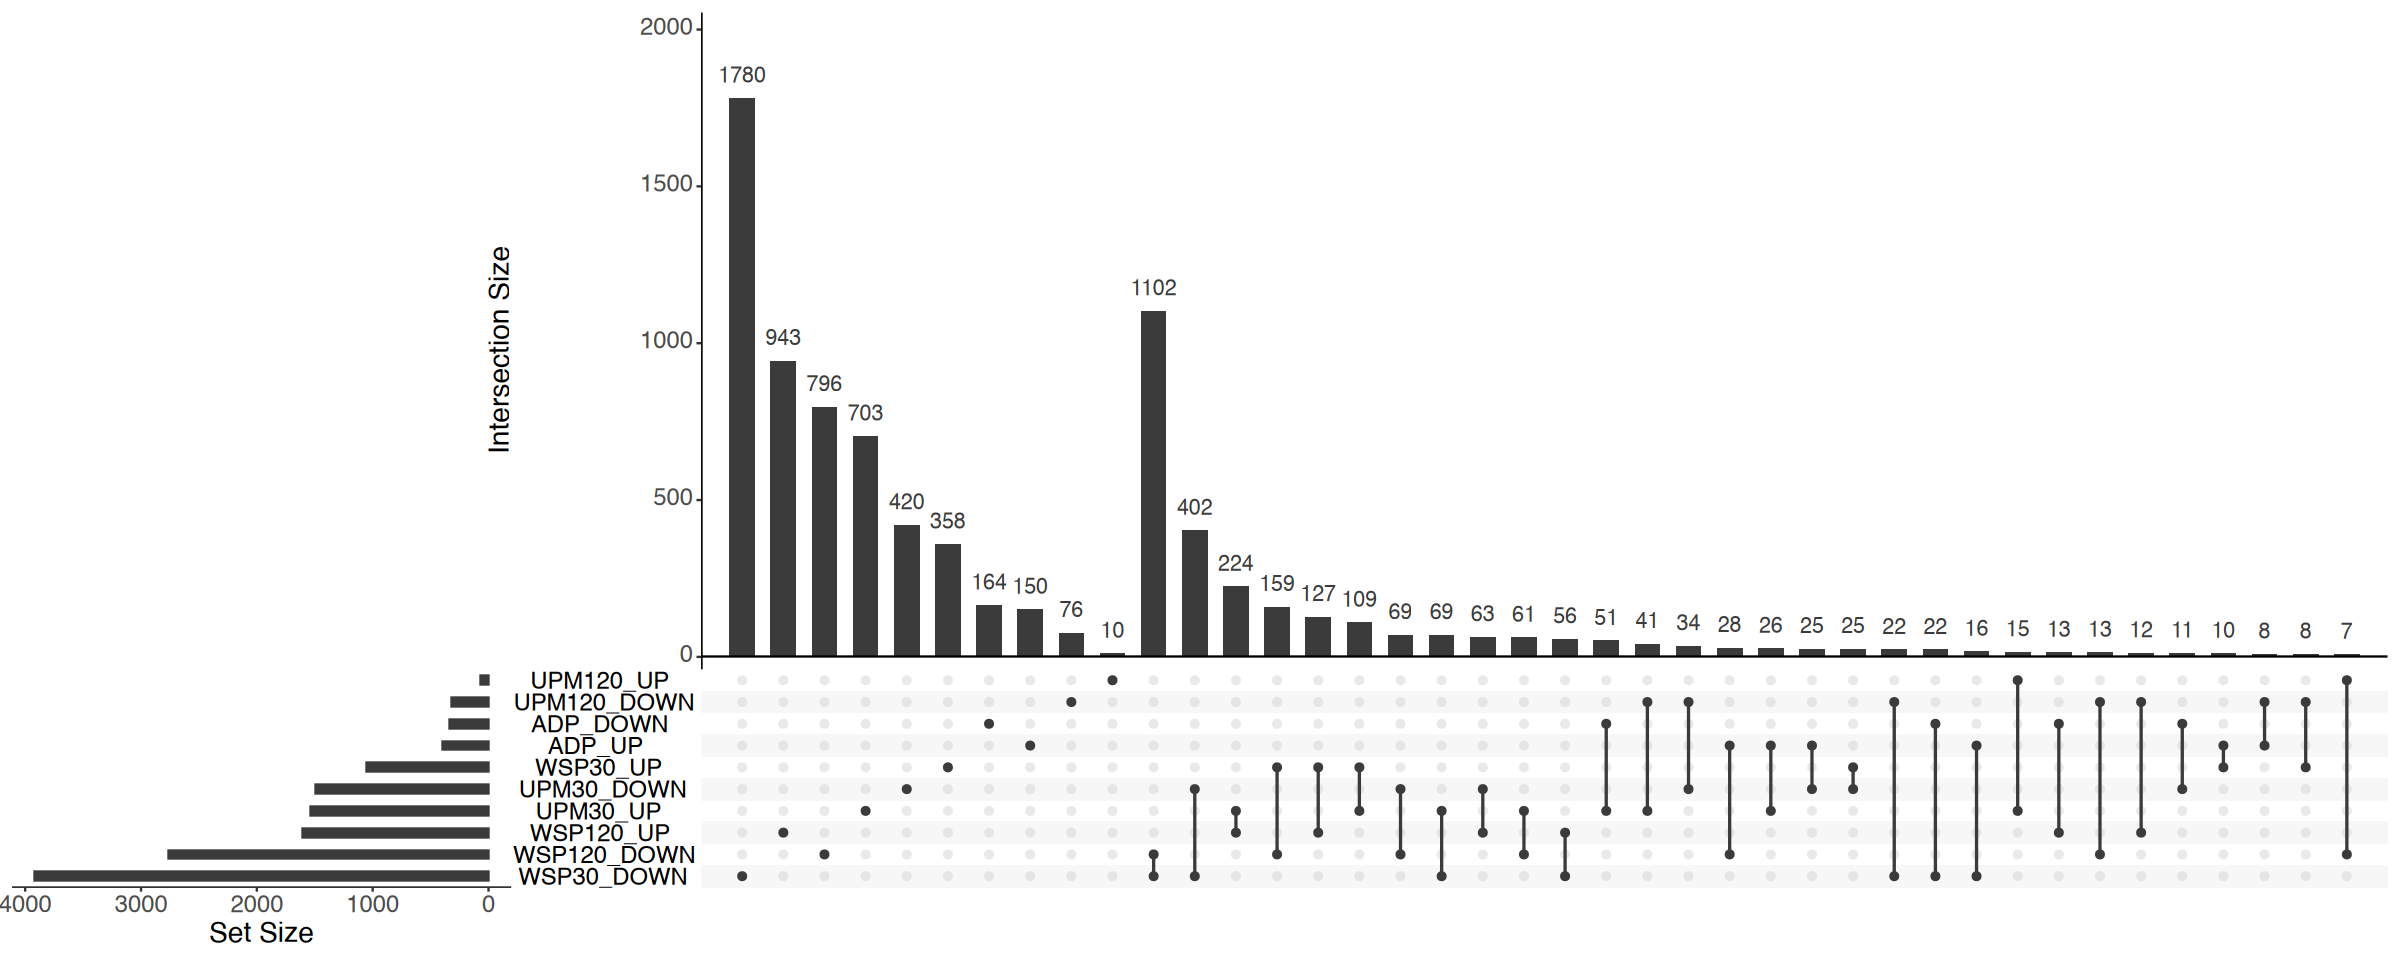

In [26]:
sig_calls = list("ADP_UP"=up_adp, "ADP_DOWN"=down_adp, 
                 "UPM30_UP"=up_upm30, "UPM30_DOWN"=down_upm30, 
                  "UPM120_UP"=up_upm120, "UPM120_DOWN"=down_upm120, 
                 "WSP30_UP"=up_wsp30, "WSP30_DOWN"=down_wsp30, 
                  "WSP120_UP"=up_wsp120, "WSP120_DOWN"=down_wsp120)
options(repr.plot.width=20, repr.plot.height=8)
upset(fromList(sig_calls), nsets=10, text.scale=2)

In [27]:
# how many would it be if I considered all sig calls genes?
all_sig_gene = union(up_adp, 
                union(down_adp, 
                      union(up_upm30, 
                            union(down_upm30, 
                                  union(up_upm120, 
                                        union(down_upm120, 
                                              union(up_wsp30, 
                                                    union(down_wsp30, 
                                                          union(up_wsp120, down_wsp120)))))))))
length(all_sig_gene)

[1] 9017

[1] 7252

[1] 3217

[1] 740

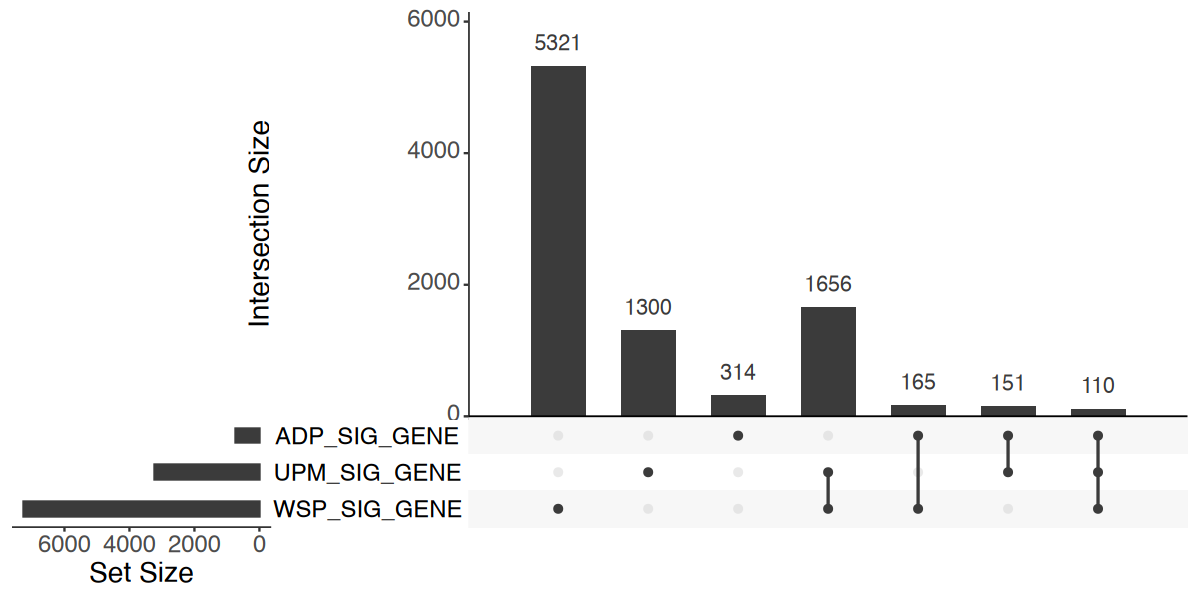

In [28]:
# only shared
upm_sig_gene = union(union(up_upm120, down_upm120), union(up_upm30, down_upm30))
wsp_sig_gene = union(union(up_wsp120, down_wsp120), union(up_wsp30, down_wsp30))
adp_sig_gene = union(up_adp, down_adp)

sig_calls = list("ADP_SIG_GENE"=adp_sig_gene, "UPM_SIG_GENE"=upm_sig_gene, 
                 "WSP_SIG_GENE"=wsp_sig_gene)
options(repr.plot.width=10, repr.plot.height=5)
upset(fromList(sig_calls), nsets=3, text.scale=2)

length(wsp_sig_gene)
length(upm_sig_gene)
length(adp_sig_gene)

In [29]:
both_sig_gene = intersect(upm_sig_gene, wsp_sig_gene)
shared_sig_gene = intersect(both_sig_gene, adp_sig_gene)
length(shared_sig_gene)
length(both_sig_gene)

[1] 110

[1] 1766

### 2C. Get the Gene TSS locations

#chrom,start,stop,"fc,p-value,rank",gene
<chr>,<int>,<int>,<chr>,<chr>
chr17,78923887,78926887,"19.5909734394284,1.45699472618573e-40,1",TIMP2
chr17,4497380,4500380,"21.2323360612102,1.11068814337312e-38,2",SPNS2


[1] 8677    5

#chrom,start,stop,"fc,p-value,rank",gene
<chr>,<int>,<int>,<chr>,<chr>
chr5,138463978,138466978,"42.871726055098,0,1",EGR1
chr6,131949872,131952872,"12.3468697800968,0,2",CCN2


[1] 8727    5

#chrom,start,stop,"fc,p-value,rank",gene
<chr>,<int>,<int>,<chr>,<chr>
chr4,138240849,138243849,"15.8323176954698,0,1",SLC7A11
chr1,207320177,207323177,"10.3758155736757,0,2",CD55


[1] 8926    5

[1] 9996

[1] 9017

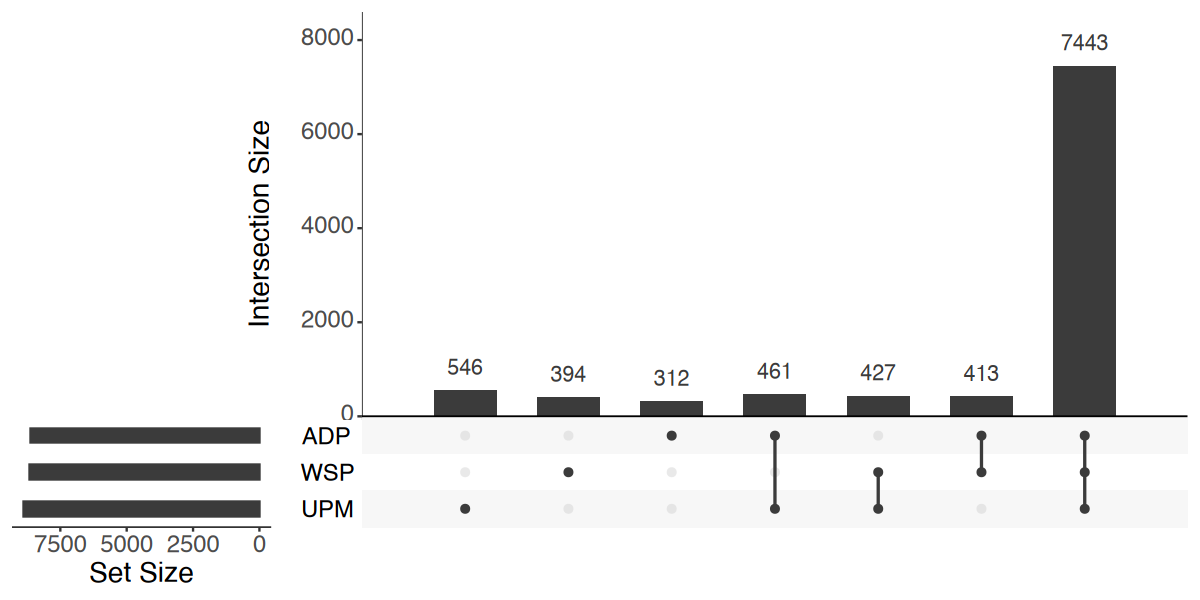

In [30]:
# Get the ranked files for TFEA
adp_gene = fread("../data/TFEA_input/GeneTSS_ADP_vs_Veh_par_rat_Wd_GeneHK.bed")
adp_gene[1:2,]
adp_gene_filt = adp_gene[adp_gene$gene %in% all_sig_gene,]
dim(adp_gene_filt)

wsp30_gene = fread("../data/TFEA_input/GeneTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed")
wsp30_gene[1:2,]
wsp30_gene_filt = wsp30_gene[wsp30_gene$gene %in% all_sig_gene,]
dim(wsp30_gene_filt)

upm30_gene = fread("../data/TFEA_input/GeneTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.bed")
upm30_gene[1:2,]
upm30_gene_filt = upm30_gene[upm30_gene$gene %in% all_sig_gene,]
dim(upm30_gene_filt)


# Check if the coordinates are the same
adp_gene_filt$coord <- paste0(adp_gene_filt[["#chrom"]], ":", adp_gene_filt$start, 
                                "-", adp_gene_filt$stop)
wsp30_gene_filt$coord <- paste0(wsp30_gene_filt[["#chrom"]], ":", wsp30_gene_filt$start, 
                                "-", wsp30_gene_filt$stop)
upm30_gene_filt$coord <- paste0(upm30_gene_filt[["#chrom"]], ":", upm30_gene_filt$start, 
                                "-", upm30_gene_filt$stop)

upset(fromList(list("ADP"=adp_gene_filt$coord, "WSP"=wsp30_gene_filt$coord, 
                    "UPM"=upm30_gene_filt$coord)), nsets=3, text.scale=2)

gene_union_tss = union(adp_gene_filt$coord, union(wsp30_gene_filt$coord, upm30_gene_filt$coord))
length(gene_union_tss)
length(all_sig_gene)

## Save the full set of 

In [32]:
# Create a named list of your vectors
all_lists <- list(
  up_adp = up_adp,
  down_adp = down_adp,
  up_upm30 = up_upm30,
  down_upm30 = down_upm30,
  up_upm120 = up_upm120,
  down_upm120 = down_upm120,
  up_wsp30 = up_wsp30,
  down_wsp30 = down_wsp30,
  up_wsp120 = up_wsp120,
  down_wsp120 = down_wsp120
)

# Get all unique names
all_sig <- unique(unlist(all_lists))

# Create a data.frame indicating membership in each list
membership_df <- data.frame(name = all_sig)

# Add a column that lists which input lists each name appears in
membership_df$source_lists <- sapply(membership_df$name, function(gene) {
  paste(names(all_lists)[sapply(all_lists, function(lst) gene %in% lst)], collapse = ", ")
})

# View the result
head(membership_df)


,name,source_lists
,<chr>,<chr>
1,TIMP2,"up_adp, down_wsp120"
2,SPNS2,"up_adp, down_upm30"
3,EMP1,"up_adp, down_upm120, up_wsp30"
4,SLCO4A1,"up_adp, down_wsp120"
5,KLK7,up_adp
6,CEP295NL,"up_adp, down_wsp30, down_wsp120"


In [33]:
# Step 1: Create named coord_lists
coord_lists <- list(
  "ADP" = adp_gene_filt$coord,
  "WSP" = wsp30_gene_filt$coord,
  "UPM" = upm30_gene_filt$coord
)

# Step 2: Combine all coords with list names
library(data.table)

# Create a data.table of coord-source mappings
coord_sources <- rbindlist(lapply(names(coord_lists), function(source_name) {
  data.table(coord = coord_lists[[source_name]], source = source_name)
}), use.names = TRUE)

# Step 3: Aggregate source membership per coord
coord_grouped <- coord_sources[, .(source_lists = paste(unique(source), collapse = ", ")), by = coord]

# Step 4: Combine gene info from all three data frames
# Assuming all coords are unique across the dfs (or at least for each coord, gene is the same)
gene_map <- rbindlist(list(
  data.table(coord = adp_gene_filt$coord, gene = adp_gene_filt$gene),
  data.table(coord = wsp30_gene_filt$coord, gene = wsp30_gene_filt$gene),
  data.table(coord = upm30_gene_filt$coord, gene = upm30_gene_filt$gene)
), use.names = TRUE)

# Remove duplicates to ensure one-to-one mapping
gene_map_unique <- unique(gene_map)

# Step 5: Merge gene info with coord_grouped
membership_coord_df <- merge(coord_grouped, gene_map_unique, by = "coord", all.x = TRUE)

# Optional: Reorder columns
membership_coord_df <- membership_coord_df[, .(coord, gene, source_lists)]

# View result
head(membership_coord_df)


coord,gene,source_lists
<chr>,<chr>,<chr>
chr10:100008447-100011447,DNMBP,WSP
chr10:100184529-100187529,ERLIN1,"ADP, WSP, UPM"
chr10:100345732-100348732,SCD,"ADP, WSP, UPM"
chr10:100372075-100375075,OLMALINC,"ADP, WSP, UPM"
chr10:100995087-100998087,LZTS2,WSP
chr10:100995570-100998570,LZTS2,ADP


In [34]:
dim(membership_coord_df)

[1] 10053     3

In [35]:
# now map the appropriate gene isoform
gene_tss <- fread("~/Downloads/assets/hg38_TSS1kb_refseq_diff53prime_with_putatives.bed")
gene_tss[1:2,]
gene_tss$TSS <- as.integer((gene_tss$V2 + gene_tss$V3)/2)
gene_tss$start <- gene_tss$TSS - 1500
gene_tss$stop <- gene_tss$TSS + 1500
gene_tss$coord <- paste0(gene_tss$V1, ":", gene_tss$start, "-", gene_tss$stop)
# check that all coordinates are accounted for
length(setdiff(membership_coord_df$coord, gene_tss$coord))

V1,V2,V3,V4,V5,V6
<chr>,<int>,<int>,<chr>,<chr>,<chr>
chr1,11373,12373,DDX11L1:NR_046018.2,.,+
chr1,28870,29870,WASH7P:NR_024540.1,.,-


[1] 0

In [36]:
# Merge gene isoform info with coord_grouped
membership_coord_df <- merge(membership_coord_df, gene_tss[,c("coord", "V4", "TSS")], by = "coord", all.x = TRUE)
membership_coord_df[1:3,]

coord,gene,source_lists,V4,TSS
<chr>,<chr>,<chr>,<chr>,<int>
chr10:100008447-100011447,DNMBP,WSP,DNMBP:NM_015221.4,100009947
chr10:100184529-100187529,ERLIN1,"ADP, WSP, UPM",ERLIN1:NM_006459.4,100186029
chr10:100345732-100348732,SCD,"ADP, WSP, UPM",SCD:NM_005063.5,100347232


### Multiple Genes can have the same TSSs so consider all and then collapse with bedtools merge

In [37]:
count_df <- as.data.frame(table(membership_coord_df$gene))
count_df[1:3,]

,Var1,Freq
,<fct>,<int>
1,A1BG,1
2,A1BG-AS1,1
3,AACS,5


In [38]:
membership_coord_df[membership_coord_df$gene == "AASS",]

coord,gene,source_lists,V4,TSS
<chr>,<chr>,<chr>,<chr>,<int>
chr7:122142749-122145749,AASS,"ADP, WSP, UPM",AASS:NM_005763.4,122144249
chr7:122142749-122145749,AASS,"ADP, WSP, UPM",AASS:XM_047419710.1,122144249
chr7:122142749-122145749,AASS,"ADP, WSP, UPM",AASS:XR_007059980.1,122144249
chr7:122142749-122145749,AASS,"ADP, WSP, UPM",AASS:XR_927326.3,122144249
chr7:122142749-122145749,AASS,"ADP, WSP, UPM",AASS:XM_047419711.1,122144249


### Save the coordinates with the gene info
1. Start with just the 100bp

In [40]:
membership_coord_df$chrom <- str_split_fixed(membership_coord_df$coord, ":", 2)[,1]
membership_coord_df$start100 <- membership_coord_df$TSS - 50
membership_coord_df$stop100 <- membership_coord_df$TSS + 50
final_genetss_df <- membership_coord_df[,c("chrom", "start100", "stop100", "V4", "source_lists")]
final_genetss_df[1:3,]

chrom,start100,stop100,V4,source_lists
<chr>,<dbl>,<dbl>,<chr>,<chr>
chr10,100009897,100009997,DNMBP:NM_015221.4,WSP
chr10,100185979,100186079,ERLIN1:NM_006459.4,"ADP, WSP, UPM"
chr10,100347182,100347282,SCD:NM_005063.5,"ADP, WSP, UPM"


In [41]:
write.table(final_genetss_df, "../results/SNP_analysis/GeneTSS_ADPWSPUPM_100bp.bed", 
            quote=FALSE, sep="\t", col.names=FALSE, row.names=FALSE)

In [42]:
dim(final_genetss_df)

[1] 15680     5

### Collapse with bedtools merge

In [43]:
checking <- fread("../results/SNP_analysis/test.bed")
checking[1:2,]
length = checking$V3 - checking$V2
unique(length)

V1,V2,V3,V4
<chr>,<int>,<int>,<chr>
chr1,919642,919742,LINC02593:NR_026874.2
chr1,923872,923972,SAMD11:NM_001385640.1


[1] 100 123 153 183 105 188 182 157 195 125 161 172 119 167 139 118 192 162 154
[20] 109 190 175 151 173 107 176 197 126 114 134 168 115 128 200 112 155 146 129
[39] 180 193 127 104 143 108 147 138 171 181 117 185 102 164 142 120 196 111 225
[58] 158 135 178 163 165 191 116 169 130 124 103 199 186 184 187 156 149 132 194
[77] 113 136 140 148 177